In [155]:
import os
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [156]:
from google.colab import drive
drive.mount('/content/drive/')
%cd '/content/drive/MyDrive/crytpo_DLOB-main/'

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content/drive/MyDrive/crytpo_DLOB-main


In [157]:
!pip install -r requirements_lujun.txt

In [158]:
!pip install pytorch-tcn

In [159]:
from tqdm import tqdm

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
import gc
import os
import sys
import yaml
from preprocessing.preprocessing import preprocess_lob_data, split_data_chronological, normalize_features
from preprocessing.dataset import create_sequences, LOBSequenceDataset, LOBLazySequenceDataset
from training.trainer import Trainer, Config
from utils.utils import print_model_info

In [160]:
with open("configs/tcn_1024_7_100.cfg", "r") as f:
    config_dict = yaml.safe_load(f)
config = Config(config_dict)

In [161]:
print(config.model.in_features)

7


In [162]:
#import torch
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#print(f"Using device: {device}")

In [163]:
!pip install torch_xla #cloud-tpu-client==0.10 https://storage.googleapis.com/tpu-pytorch/wheels/torch_xla-1.13-cp310-cp310-linux_x86_64.whl

In [164]:
import torch_xla
import torch_xla.core.xla_model as xm

# Set the device to use TPU
device = xm.xla_device()
print(f"Using device: {device}")

Using device: xla:0


In [165]:
print(os.getcwd())

/content/drive/MyDrive/crytpo_DLOB-main


In [166]:
# --- 1. Preprocess Data ---
df_processed = preprocess_lob_data(config)
gc.collect()

Memory Usage: 1543.83 MB
Shape before cleaning (dropna): (4817923, 81)
NaN count before: 0
Shape after cleaning: (4817923, 81)
NaN count after: 0
Calculating alpha dynamically...
Dynamic alpha = 0.000108
Shape after label creation and NaN drop: (4817723, 8)
Label distribution:
label
1    0.450598
2    0.277158
0    0.272244
Name: proportion, dtype: float64
Saving preprocessed data to results/...
Save complete.


0

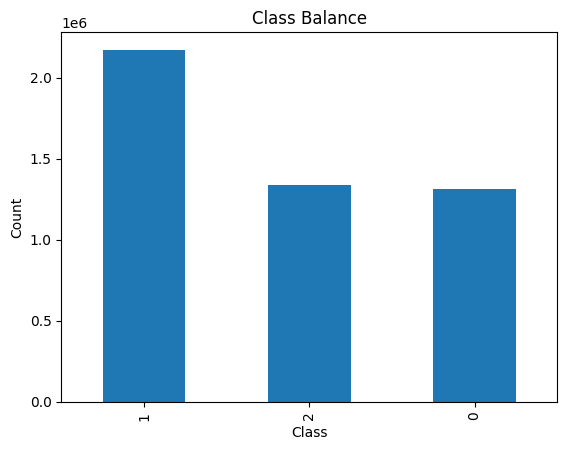

In [167]:
import matplotlib.pyplot as plt
class_counts = df_processed['label'].value_counts()
# Plot
class_counts.plot(kind='bar')
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [168]:
# --- 2. Split Data ---
train_df, val_df, test_df = split_data_chronological(
    df_processed,
    train_frac=config_dict['split_fractions']['train'],
    val_frac=config_dict['split_fractions']['val'],
    test_frac=config_dict['split_fractions']['test']
)
del df_processed
gc.collect()

Data Split: Train=3372406, Val=722658, Test=722659


2835

In [169]:
train_df.head()

,b0,a0,bq0,aq0,mid_price,spread,vol_imbalance_1,label
100,70207.351562,69437.117188,0.1147,0.008940,69822.234375,-770.234375,0.855383,2
101,70207.351562,69440.851562,0.1147,0.000003,69824.101562,-766.500000,0.999946,2
102,70207.351562,69448.898438,0.1147,0.003000,69828.125000,-758.453125,0.949023,2
103,70207.351562,69443.328125,0.1147,0.003000,69825.343750,-764.023438,0.949023,2
104,70207.351562,69445.921875,0.1147,0.000003,69826.640625,-761.429688,0.999956,2


In [170]:
#if config.precision == 'float16' or None:
#    precision = np.float16
#elif config.precision == 'float32':
#    precision = np.float32
#elif config.precision == 'float64':
#    precision = np.float64
#
#print(f"Precision is: {precision}")

In [171]:
# --- 3. Normalize Features ---

# Select ONLY numeric feature columns for scaling
# Exclude the 'label' column as well
numeric_cols = train_df.select_dtypes(include=np.number).columns
feature_cols = [col for col in numeric_cols if col != 'label']

# Optional: Print to verify which columns are being scaled
print(f"Columns selected for scaling ({len(feature_cols)}): {feature_cols[:10]}...") # Print first 10

# Check if feature_cols is empty
if not feature_cols:
    raise ValueError("No numerical feature columns found for scaling after excluding 'label'.")

# Call normalize_features with the correctly filtered list
train_df_norm, val_df_norm, test_df_norm, scaler = normalize_features(
    train_df, val_df, test_df, feature_cols
)
train_df_norm.loc[:, "label"] = train_df.loc[:, "label"].copy()
val_df_norm.loc[:, "label"] = val_df.loc[:, "label"].copy()
test_df_norm.loc[:, "label"] = test_df.loc[:, "label"].copy()
del train_df, val_df, test_df
gc.collect()

Columns selected for scaling (7): ['b0', 'a0', 'bq0', 'aq0', 'mid_price', 'spread', 'vol_imbalance_1']...
Normalization applied.


0

In [172]:
train_df_norm.head()

,b0,a0,bq0,aq0,mid_price,spread,vol_imbalance_1,label
100,-1.13511,-1.249706,-0.105997,-0.064608,-1.197122,-0.879738,1.091485,2
101,-1.13511,-1.248787,-0.105997,-0.067792,-1.196655,-0.874096,1.279588,2
102,-1.13511,-1.246806,-0.105997,-0.066724,-1.195649,-0.861939,1.213328,2
103,-1.13511,-1.248177,-0.105997,-0.066724,-1.196345,-0.870354,1.213328,2
104,-1.13511,-1.247539,-0.105997,-0.067792,-1.196020,-0.866436,1.279601,2


In [173]:
config.sequence_length = 100

In [174]:
# --- 4. Create Sequences ---
# Separate features and labels before sequencing
y_train_series = train_df_norm.pop('label').values
X_train_features = train_df_norm[feature_cols].astype(np.float32).values

y_val_series = val_df_norm.pop('label').values
X_val_features = val_df_norm[feature_cols].astype(np.float32).values

y_test_series = test_df_norm.pop('label').values
X_test_features = test_df_norm[feature_cols].astype(np.float32).values

T = config.sequence_length
# Toggle whether to use lazy (on-the-fly) sliding windows or pre-built sequences
use_lazy_sequences = True
if use_lazy_sequences:
    train_dataset = LOBLazySequenceDataset(
        features=X_train_features,
        labels=y_train_series,
        seq_len=T,
        stride=10,
        device=device
    )

    val_dataset = LOBLazySequenceDataset(
        features=X_val_features,
        labels=y_val_series,
        seq_len=T,
        stride=10,
        device=device
    )

    test_dataset = LOBLazySequenceDataset(
        features=X_test_features,
        labels=y_test_series,
        seq_len=T,
        stride=10,
        device=device
    )
else:
    X_train_seq, y_train_seq = create_sequences(X_train_features, y_train_series, T, precision)
    X_val_seq, y_val_seq = create_sequences(X_val_features, y_val_series, T, precision)
    X_test_seq, y_test_seq = create_sequences(X_test_features, y_test_series, T, precision)

    train_dataset = LOBSequenceDataset(X_train_seq, y_train_seq, device=device)
    val_dataset   = LOBSequenceDataset(X_val_seq,   y_val_seq,   device=device)
    test_dataset  = LOBSequenceDataset(X_test_seq,  y_test_seq,  device=device)


del train_df_norm, val_df_norm, test_df_norm # Free memory
del X_train_features, y_train_series, X_val_features, y_val_series, X_test_features, y_test_series
gc.collect()

0

In [175]:
config.model.in_features = config.num_levels_features * 4 + 3

In [176]:
trainer = Trainer(config, train_dataset, val_dataset, test_dataset, torch.device(device))

One batch shape: torch.Size([1024, 7, 100])

Datasets and DataLoaders created.
Number of training batches: 330
Number of validation batches: 71
Number of testing batches: 71
Input Size: torch.Size([1024, 7, 100])
device used in trainer: xla:0
input.shape: (337231, 100, 7)
Model: TCN model

🧠 Total parameters: 6,291
🎯 Trainable parameters: 6,291


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [177]:
print(trainer._get_device())

Using TPU (xla:0).
xla:0


In [178]:
print(trainer.device)

xla:0


In [ ]:
trainer.train()

Starting Training
Epochs: 20 | Num Batches: 330
